CSI4142 - Fundementals of Data Science - Assignment 1

Jamie Bly - 300231604,
Sameed Jafri - 300253861
____

For our first analysis, we are going to be exploring the German Credit Risk dataset. This data represents person who have taken out credit with a bank, and can be used by banks or other lenders to determine whether the persion is a good or bad credit risk.

Dataset 1:

German Credit Risk, UCI Learning, Credit Classification

Size: 10 Columns, 1000 Rows

Features

    Age (Numeric)

    Sex (Categorical)

    Job (Categorical)

    Housing (Categorical)

    Savings Account (Categorical)

    Checking Account (Categorical)

    Credit Ammount (Numeric)

    Duration (Numeric)

    Purpose (Categorical)

Redundancies/Missing Values

    I feel that the Savings and Checking Account being binned in this case makes our analysis more difficult, as we are now unable to perform our own binning or establish our own definition of what is "Little, moderate, quite rich or rich"
    The fact that there is only one column for credit per person limits the amount of data analysis we can do, as most people will have multiple debts, for example a mortgage and Car Financing. 


In [2]:
#Import dataset from Kaggle to pandas

# Install dependencies as needed:
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd

# Set the path to the file you'd like to load
file_path = "german_credit_data.csv"

# Load the latest version
credit_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/german-credit",
  file_path,
)

print("First 5 records:", credit_df.head())

/tmp/ipykernel_20293/678247264.py:16: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  credit_df = kagglehub.load_dataset(


First 5 records:    Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  
0           1169         6             radio/TV  
1           5951        48             radio/TV  
2           2096        12            education  
3           7882        42  furniture/equipment  
4           4870        24                  car  


Insight 1: The large majority of people with debts are between the ages of 20 and 40 years old.

Analsis Type: Boxplot, Histogram and Summary Statistics

How evidence was obtained: Univariate Analysis (Numerical) R1 ---> Histogram and Statiscal Summary. The histogrma is right skewed, meaning that most of the values fall on the right side of the graph, which shows that debts are more likley to be owed by younger people, specifically people between 20 and 40 years old.



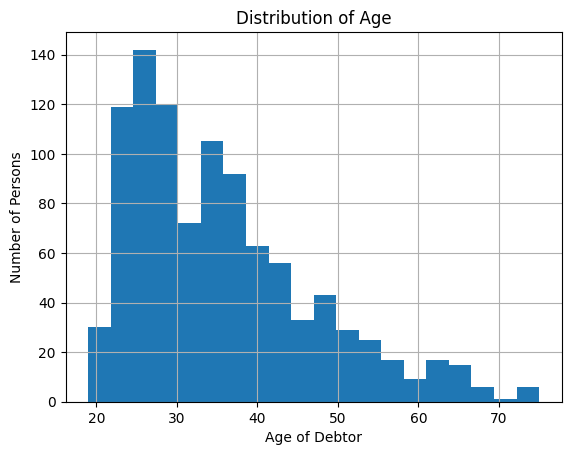

,Age
count,1000.000000
mean,35.546000
std,11.375469
min,19.000000
25%,27.000000
50%,33.000000
75%,42.000000
max,75.000000


In [3]:
credit_df[['Age']].hist(bins=20)

plt.title("Distribution of Age")
plt.xlabel("Age of Debtor")
plt.ylabel("Number of Persons")
plt.show()

credit_df[["Age"]].describe()



Insight 2: The vast majority of the debts purposes are Car, TV/Radio and Equipment/Furniture, which comprises more than 75% of all debts.

Analsis Type: Count Plot

How evidence was obtained: Univariate Analysis (Categorical R2) ---> Count Plot. By looking at the count plot graph, and combining the shown percentages, you can see that Car, Radio/TV and Equipment/Furniture hold the vast majority of debts (79.8% of all debts).



/tmp/ipykernel_16207/2385500606.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


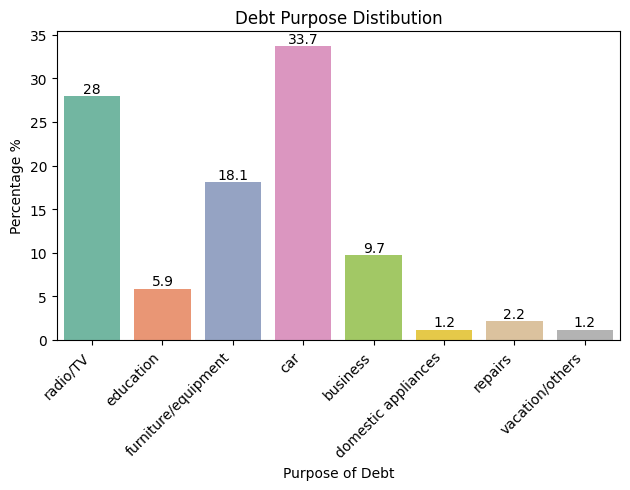

In [4]:
palette = sns.color_palette("Set2", credit_df['Purpose'].nunique())
ax = sns.countplot(x="Purpose", data=credit_df, hue='Purpose', palette=palette, stat='percent')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.ylabel("Percentage %")
plt.xlabel("Purpose of Debt")
plt.title("Debt Purpose Distibution")

for c in ax.containers:
    ax.bar_label(c)
    
plt.show()

Insight 3: The majority of the debts belong to with persons with skilled jobs. 

Analsis Type: Count Plot

How evidence was obtained: Univariate Analysis (Categorical R3) ---> Count Plot. For this insight, I decided to group the 0 - Unskilled and Non-resident and 1 - Unskilled and Resident, as the designation between resident and non-resident doesn't provide additional information for analysis to the value that their occupation holds, and their occupations ability to provide for them to repay their debt.

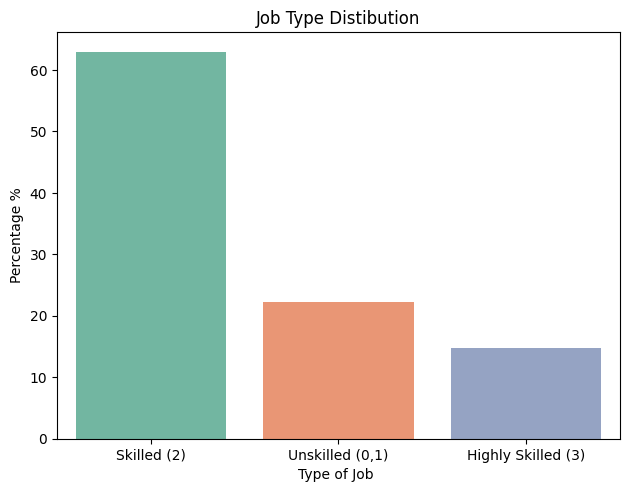

In [5]:
credit_df["Combined_Job"] = credit_df['Job'].map({
    0: "Unskilled (0,1)",
    1: "Unskilled (0,1)",
    2: "Skilled (2)",
    3: "Highly Skilled (3)"
})
palette = sns.color_palette("Set2", credit_df['Combined_Job'].nunique())

ax = sns.countplot(x="Combined_Job", data=credit_df, hue='Combined_Job', palette=palette, stat='percent')

plt.tight_layout()
plt.ylabel("Percentage %")
plt.xlabel("Type of Job ")
plt.title("Job Type Distibution")
plt.show()

Insight 4: While debts related to cars or Radio/televisions may be the most popular debts, business loans hold the highest average credit amount of purposes with a uniform distribution.

Analsis Type: Boxplot and Swarmplot

How evidence was obtained: Bivariate Analysis (Categorical/Numerical R4) ---> Boxplot, Swarmplot. For this insight, by looking at swarmplot, you can see that both car and radio credits are more densly clustered around the bottom of the graph, and become less dense as you ascend the Y-axis. While business loans do decrease as well, it has a less steep decline, and you can see in the boxplot that the average is significantly higher and has a higher floor for the general range.  

/home/m33d/development/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_16207/4444883.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/home/m33d/development/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/m33d/development/CSI4142_FundementalsOfDataScience_A1/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 7.4% of the points cannot be placed; you may want to decrease the size of the mark

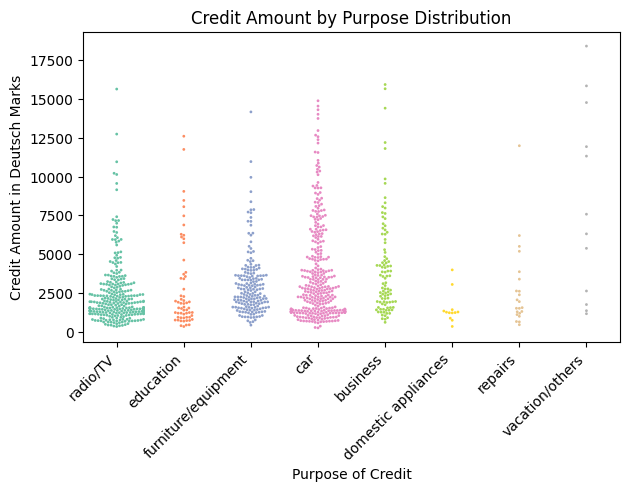

/tmp/ipykernel_16207/4444883.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bx.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


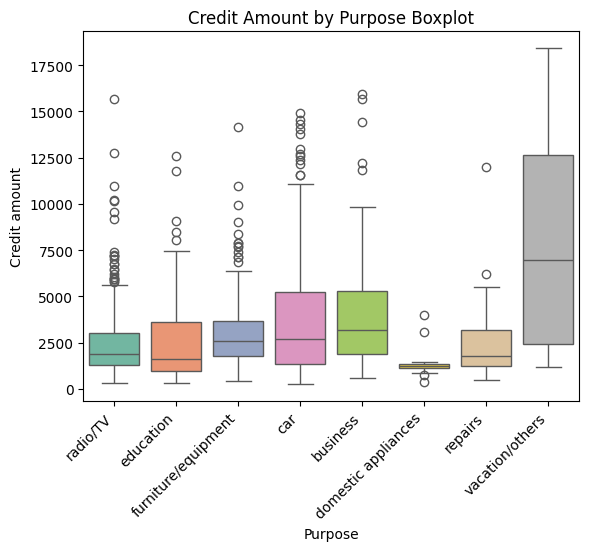

In [6]:
palette = sns.color_palette("Set2", credit_df['Purpose'].nunique())

ax = sns.swarmplot(x="Purpose", data=credit_df, y='Credit amount', hue="Purpose", palette=palette, size=2)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.ylabel("Credit Amount in Deutsch Marks")
plt.xlabel("Purpose of Credit")
plt.title("Credit Amount by Purpose Distribution")
plt.show()

bx = sns.boxplot(data=credit_df, x='Purpose', y='Credit amount', hue='Purpose', palette=palette)
bx.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title("Credit Amount by Purpose Boxplot")
plt.show()

Insight 5: Female debtors are comparatively more likely to be renting than Male Debtors. 

Analsis Type: Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Categorical R5) ---> Countplot. When looking at the countplot, you can see that when comparing Renters VS Own and Free, that female debtors that are women and renting are a significantly larger percentage of the total than when compared to the male renters.

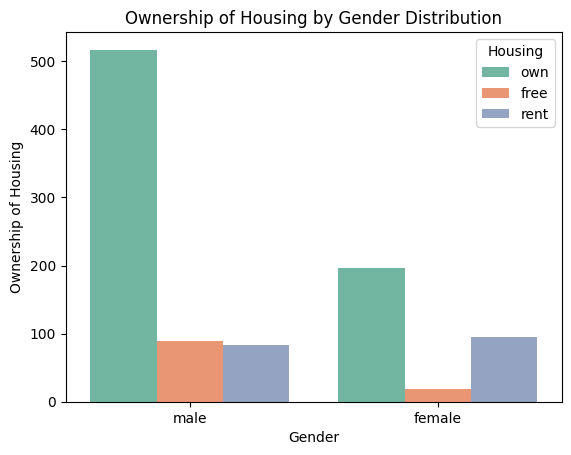

In [7]:
palette = sns.color_palette("Set2", credit_df['Housing'].nunique())

ax = sns.countplot(x="Sex", data=credit_df, hue="Housing", palette=palette)

plt.ylabel("Ownership of Housing")
plt.xlabel("Gender")
plt.title("Ownership of Housing by Gender Distribution")
plt.show()

Insight 6: Women are comparatively more likely to take on a debt for Education, Furniture/Equipment or domestic appliances than men. 

Analsis Type: Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Categorical R6) ---> Countplot. When looking at the countplot, you can see that when comparing the three mentioned categories (Education, Furniutre/Equipment and Domestic appliances), that women hold a comparatively higher number of debts than other purposes.These category have women accounting for well over 40% of all debts, despite having an overall population of around 30%.

/tmp/ipykernel_16207/3070756508.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


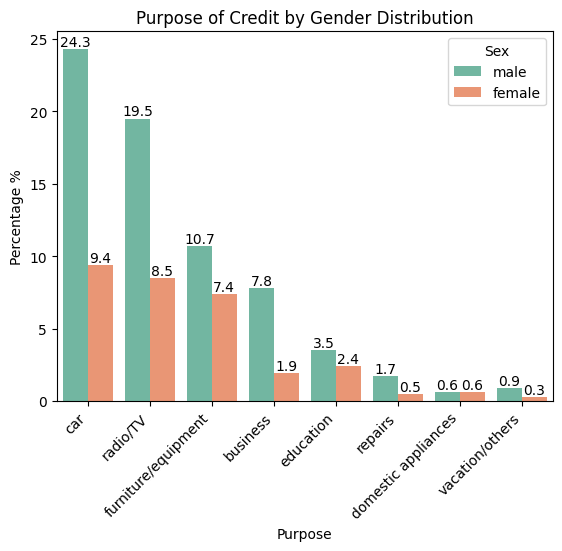

In [8]:
palette = sns.color_palette("Set2", credit_df['Sex'].nunique())

ax = sns.countplot(x="Purpose", data=credit_df, hue="Sex", palette=palette, order=credit_df['Purpose'].value_counts().index, hue_order=['male', 'female'], stat='percent')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel("Percentage %")
plt.xlabel("Purpose")
plt.title("Purpose of Credit by Gender Distribution")

for c in ax.containers:
    ax.bar_label(c)
    
plt.show()



Insight 7: The younger that a debtor is, the higher the likelihood that they have an Skilled Job is, and the older they are, the more likely they are to be highly skilled.

Analsis Type: Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Numeric R7) ---> Countplot. First we split the age into bins using pandas cut function to split it into 8 differnet bins, then we show the binned ages with the previously created Combined_Job as the hue.

/tmp/ipykernel_16207/40318702.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


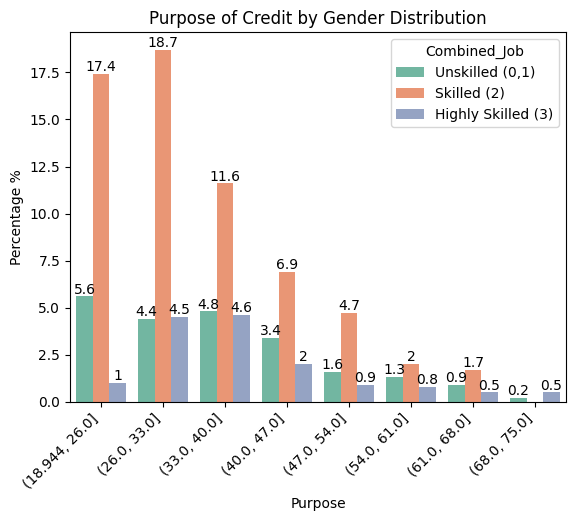

In [9]:
palette = sns.color_palette("Set2", credit_df['Combined_Job'].nunique())

credit_df['Binned_Age'] = pd.cut(credit_df['Age'], 8)

ax = sns.countplot(x="Binned_Age", data=credit_df, hue="Combined_Job", palette=palette, stat='percent', hue_order=['Unskilled (0,1)', 'Skilled (2)', 'Highly Skilled (3)'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.ylabel("Percentage %")
plt.xlabel("Purpose")
plt.title("Purpose of Credit by Gender Distribution")

for c in ax.containers:
    ax.bar_label(c)
    
plt.show()


Insight 8: There is a moderate, positive correlation between the duration of the debt and the Credit amount owed.

Analsis Type: Scatterplot

How evidence was obtained: Bivariate Analysis (Numberical/Numerical R8) ---> A scatterplot of Duration vs Credit Amount that shows a general upwards trend, which demonstrates a moderate, positive correlation between the Amount owed and the duration.

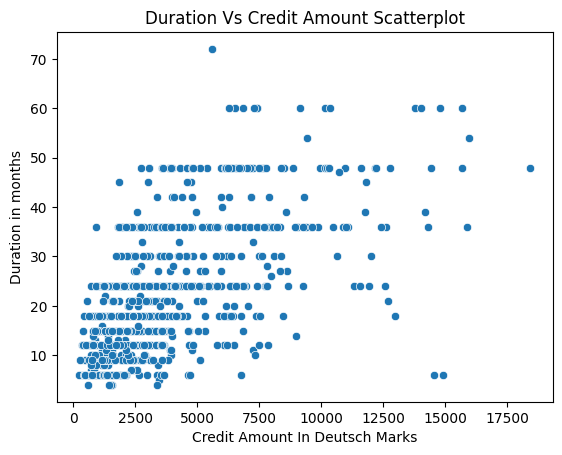

In [10]:
ax = sns.scatterplot(x="Credit amount", data=credit_df, y="Duration")

plt.ylabel("Duration in months")
plt.xlabel("Credit Amount In Deutsch Marks")
plt.title("Duration Vs Credit Amount Scatterplot")
    
plt.show()


Insight 9: Debtors with High Skilled jobs have a higher debt duration on average than other jobs

Analsis Type: Boxplot

How evidence was obtained: Bivariate Analysis (Categorical/Numerical) ---> A boxplot of Duration by the debtors job type.

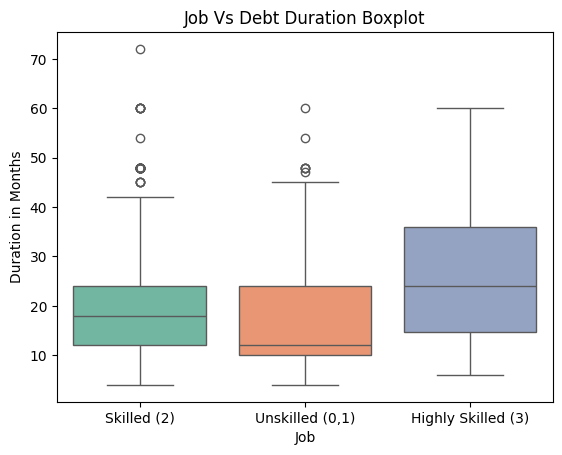

In [11]:
palette = sns.color_palette("Set2", credit_df['Combined_Job'].nunique())
sns.boxplot(x="Combined_Job", y="Duration", hue="Combined_Job", data=credit_df, palette=palette)

plt.title("Job Vs Debt Duration Boxplot")
plt.xlabel("Job")
plt.ylabel("Duration in Months")
plt.show()

Insight 10: There is a negligible correlation between Age and the following three numeric values (Job, Duration, Credit Amount)

Analsis Type: Heatmap

How evidence was obtained: Bivariate Analysis (Numerical/Numerical) ---> A heatmap of showing the correlations between Credit amount, job, duration and age shows that while there is a either a weak or moderate correlation between credit amount, job and duration, there is no correlation between any of those 3 and Age, as they are all approximately 0.

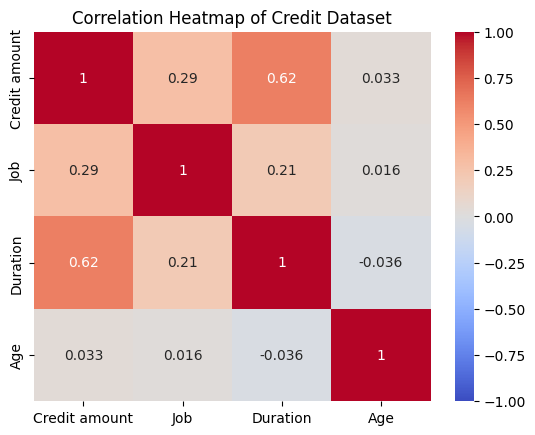

In [12]:
cols = ["Credit amount", "Job", "Duration", "Age"]
corr = credit_df[cols].corr()

sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap of Credit Dataset")
plt.show()

For our Second analysis, we are going to be exploring the Cybersecurity intrusion detection dataset. This data contains patterns for detecting cyber intrusions based on network traffic and user behaviour. This can be used to help researchers train machine learning models to detect potential security threats in real-time. 

Dataset 2:

Cybersecurity Intrusion Detection by dnkumars (via kaggle)

Shape: 11 Columns, 9537 Rows

Features

    network_packet_size (Numeric)

    protocol_type (Categorical)

    encryption_used (Categorical)

    login_attempts (Numeric)

    session_duration (Numeric)

    failed_logins (Numeric)

    ip_reputation_score (Numeric)

    browser_type (Categorical)

    unusual_time_access (Categorical)
    
    attack_dectected (Categorical)

Target Audience
    Intended for Network Security Analysts and System Adiministrators. The insights provided aim to help them understand common attack vectors, such as brute-force attempts and unsual access patterns. to better calibrate their intrusion dectection systems. 

Redundancies/Missing Values

  The dataset contains 1,966 missing values in the encryption_used column. To avoid losing 20% of the observations, these were handled by encoding them as a new category labeled "Unknown", ensuring the analysis accounts for potential non-standardized network sessions.

In [3]:
#Import dataset from Kaggle to pandas
# Set the path to the file you'd like to load
file_path = "cybersecurity_intrusion_data.csv"

# Load the latest version
cyber_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dnkumars/cybersecurity-intrusion-detection-dataset",
  file_path,
)

print("First 5 records:", cyber_df.head())

/tmp/ipykernel_20293/4029358376.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  cyber_df = kagglehub.load_dataset(


First 5 records:   session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472           TCP               3   
2  SID_00003                  629           TCP               3   
3  SID_00004                  804           UDP               4   
4  SID_00005                  453           TCP               5   

   session_duration encryption_used  ip_reputation_score  failed_logins  \
0        492.983263             DES             0.606818              1   
1       1557.996461             DES             0.301569              0   
2         75.044262             DES             0.739164              2   
3        601.248835             DES             0.123267              0   
4        532.540888             AES             0.054874              1   

  browser_type  unusual_time_access  attack_detected  
0         Edge                    0                1  
1      Firefox     

In [6]:
# Preliminary Check for Redundancy and Missing Values
print("--- Dataset Shape ---")
print(cyber_df.shape)

print("\n--- Missing Values Count ---")
print(cyber_df.isnull().sum())

print("\n--- Data Types and Non-Null Counts ---")
print(cyber_df.info())

print("\n--- Unique Values in Categorical Features ---")
for col in cyber_df.select_dtypes(include=['str', 'int64']).columns:
    print(f"{col}: {cyber_df[col].nunique()} unique values")

--- Dataset Shape ---
(9537, 11)

--- Missing Values Count ---
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

--- Data Types and Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537

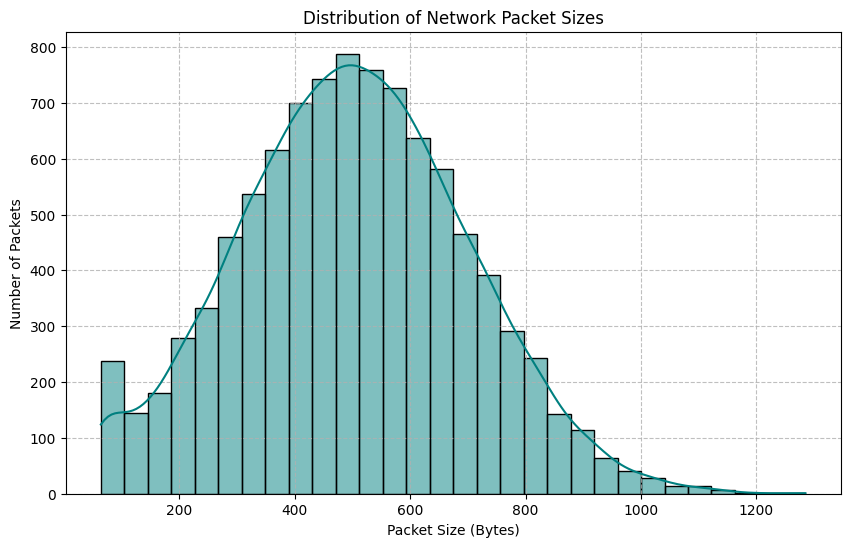

,network_packet_size
count,9537.000000
mean,500.430639
std,198.379364
min,64.000000
25%,365.000000
50%,499.000000
75%,635.000000
max,1285.000000


In [39]:

# r1: Histogram for visualization of dispersion
plt.figure(figsize=(10, 6))
sns.histplot(cyber_df['network_packet_size'], bins=30, kde=True, color='teal')
plt.title('Distribution of Network Packet Sizes')
plt.xlabel('Packet Size (Bytes)')
plt.ylabel('Number of Packets')
plt.grid(linestyle='--', alpha=0.8)
plt.show()
cyber_df[['network_packet_size']].describe()

Insight 1: The majority of the packets fall between the 400-600 byte size. Packets within this range provide a baseline for "normal" packet sizes while extremes at the 1200 byte size mark could indicate an anomoly. 

Analsis Type: Histogram and Summary Statistics

How evidence was obtained: Univariate Analysis (Numerical) R1 ---> Histogram and Statiscal Summary. The histogram is right skewed, meaning that most of the values fall on the left side of the graph, which shows that packet sizes are more likley to be within the 400-600 range then in the 1000+ range. 



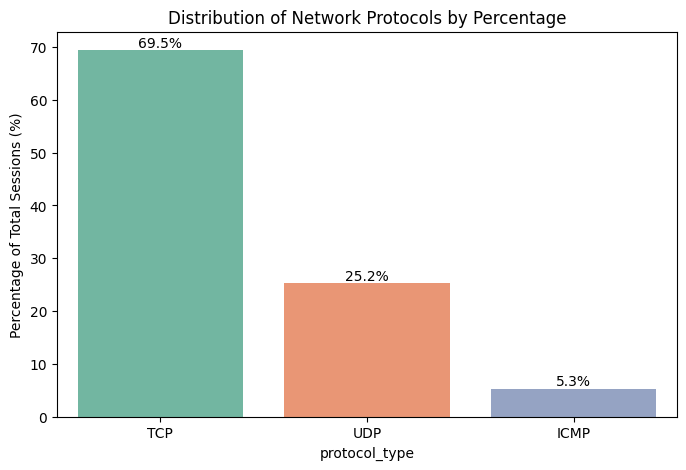

In [74]:
# r2: Percent-based distribution for protocol type
plt.figure(figsize=(8, 5))
palette = sns.color_palette("Set2", cyber_df['protocol_type'].nunique())
ax = sns.countplot(data=cyber_df, x='protocol_type', stat='percent', palette=palette, hue='protocol_type', order=cyber_df['protocol_type'].value_counts().index, legend=False)

# Add percentage labels on top of the bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%')

plt.title('Distribution of Network Protocols by Percentage')
plt.ylabel('Percentage of Total Sessions (%)')
plt.show()

Insight 2: Tcp is the most common network protocol, while ICMP accounts for a smaller portion of the traffic which is standard in most networks.

Analsis Type: Count Plot 

How evidence was obtained: Univariate Analysis (Categorical R2) ---> Count Plot. By looking at the count plot graph, you can see tcp is the majority protocol type used. 



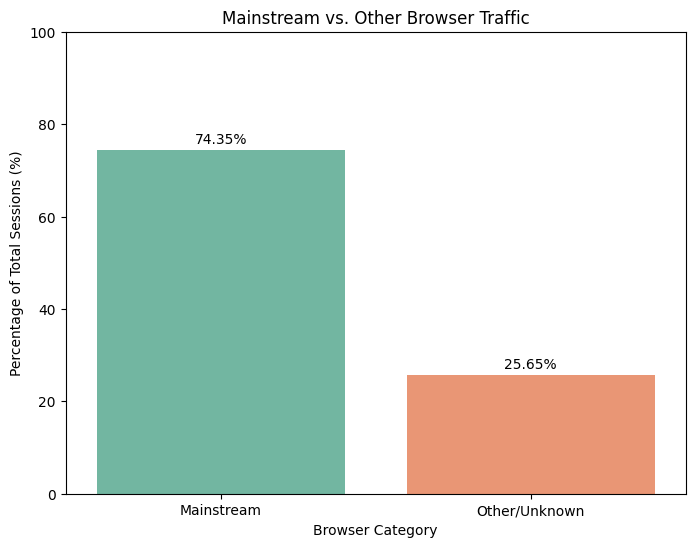

In [44]:
# r3: Grouped-Data countplot
# Define the grouping logic
mainstream = ['Chrome', 'Edge', 'Safari', 'firefox']

# Create a new temporary column for the grouped data
cyber_df['browser_group'] = cyber_df['browser_type'].apply(
    lambda x: 'Mainstream' if x in mainstream else 'Other/Unknown'
)

plt.figure(figsize=(8, 6))

# Use the 'stat' parameter to calculate percentages automatically
ax = sns.countplot(data=cyber_df, x='browser_group', palette='Set2', hue='browser_group', stat="percent", legend=False)

# Add the labels to the top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.title('Mainstream vs. Other Browser Traffic')
plt.xlabel('Browser Category')
plt.ylabel('Percentage of Total Sessions (%)')
plt.ylim(0, 100) # Set limit to 110% so labels fit

# Explanation for grouping choice: 
# "We grouped Chrome, Firefox, Edge, and Safari into 'Mainstream' to define 
# the baseline user environment. Non-standard or 'Unknown' browsers are 
# grouped to highlight potential anomalies in access methods."
plt.show()

Insight 3: grouping network traffic from various browsers into mainstream or not reaveals 74% of the sessions originate from mainstream browsers, making other browsers a point of interest in security monitoring.  

Analsis Type: Count Plot

How evidence was obtained: Univariate Analysis (Categorical R3) ---> Count Plot. For this insight, I decided to group the widely known browsers like firefox, chrome, safari, and edge into one category named mainstream and all other into another category named other/unknown for easy analysis. 

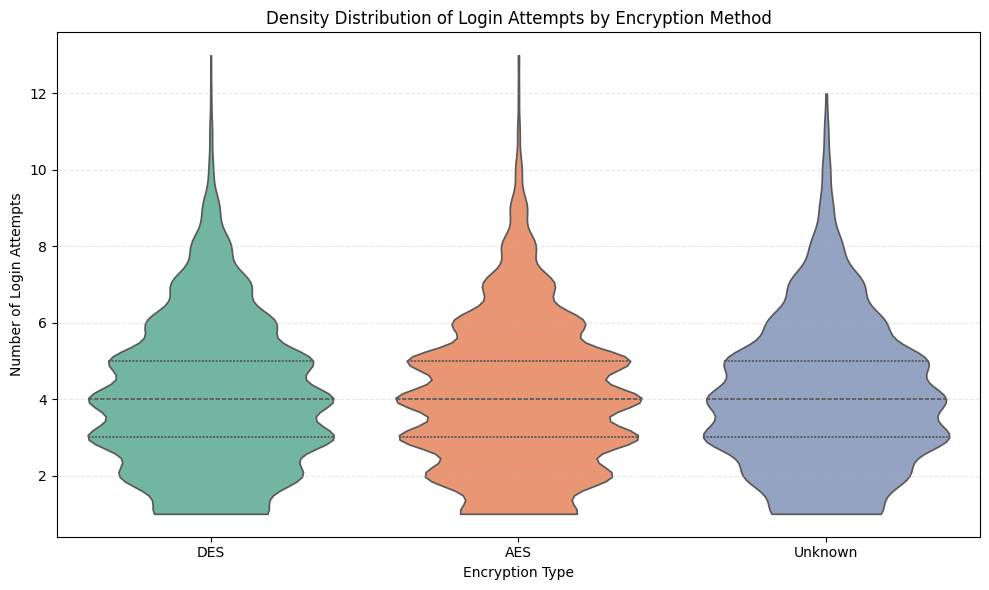

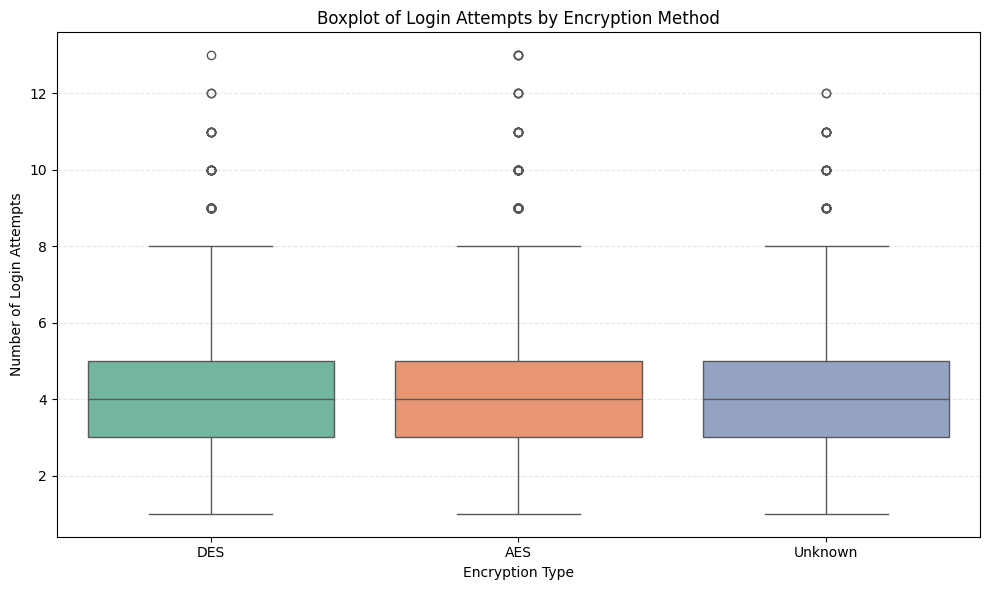

Statistical Summary of Login Attempts by Encryption:


,count,mean,std,min,25%,50%,75%,max
encryption_used,,,,,,,,
AES,4706.0,4.03,1.96,1.0,3.0,4.0,5.0,13.0
DES,2865.0,4.04,1.96,1.0,3.0,4.0,5.0,13.0
Unknown,1966.0,4.03,1.96,1.0,3.0,4.0,5.0,12.0


In [69]:
# 1. Handle missing values
cyber_df['encryption_used'] = cyber_df['encryption_used'].fillna('Unknown')


# --- Plot 1: Violin Plot (Focus on Density) ---
plt.figure(figsize=(10, 6))
ax1 = sns.violinplot(
    data=cyber_df, 
    x="encryption_used", 
    y='login_attempts', 
    palette='Set2', 
    hue="encryption_used",
    inner='quartile',  # Shows the internal stats clearly
    cut=0,             # Stops the plot from showing impossible negative logins
    legend=False
)

plt.title("Density Distribution of Login Attempts by Encryption Method")
plt.xlabel("Encryption Type")
plt.ylabel("Number of Login Attempts")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Boxplot (Focus on Outliers) ---
plt.figure(figsize=(10, 6))
ax2 = sns.boxplot(
    data=cyber_df, 
    x="encryption_used", 
    y='login_attempts', 
    palette='Set2',
    hue="encryption_used",
    legend=False
)

plt.title("Boxplot of Login Attempts by Encryption Method")
plt.xlabel("Encryption Type")
plt.ylabel("Number of Login Attempts")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary Statistics for "Supporting Evidence" (Requirement r4)
print("Statistical Summary of Login Attempts by Encryption:")
display(cyber_df.groupby('encryption_used')['login_attempts'].describe().round(2))

Insight 4: Login attempts greater than 8 could indicate a brute force attempt.

Analsis Type: Boxplot and violin density

How evidence was obtained: Bivariate Analysis (Categorical/Numerical R4) ---> Boxplot, violin density. For this insight, by looking at the box plot attempts higher than 8 are outliers indicating an anomoly. the violin plot shows thin density at the range as range supporting this. 

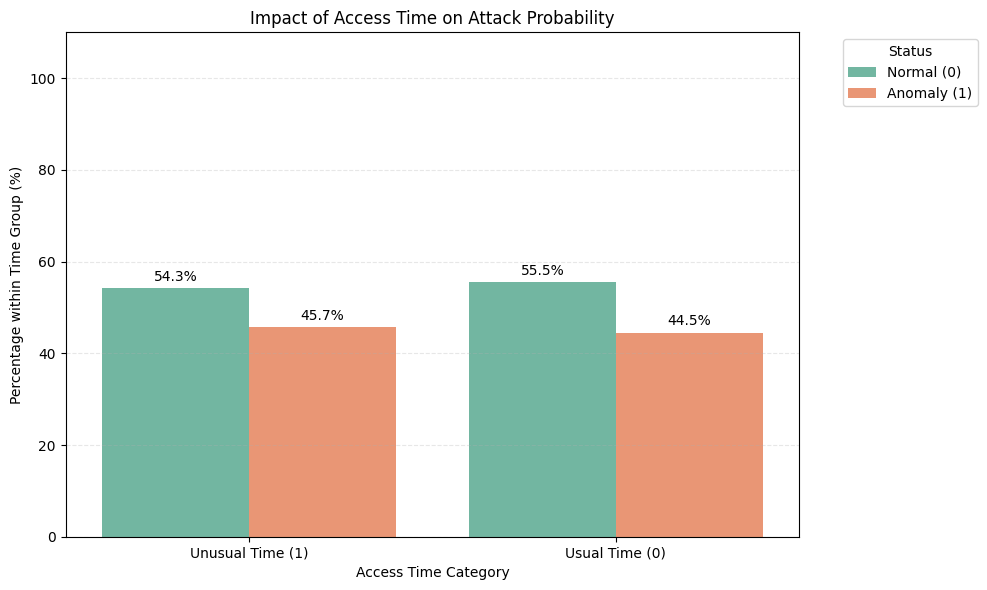

In [40]:
# r5: Categorical/Categorical Analysis (Time Access vs. Attack Detected)

# 1. Map values to descriptive strings for a self-explanatory plot
cyber_df['Time Category'] = cyber_df['unusual_time_access'].map({0: 'Usual Time (0)', 1: 'Unusual Time (1)'})
cyber_df['Attack Status'] = cyber_df['attack_detected'].map({0: 'Normal (0)', 1: 'Anomaly (1)'})

# 2. Calculate proportions WITHIN each time group
# This ensures that both 'Usual Time' and 'Unusual Time' each sum to 100%
props_time = (cyber_df.groupby("Time Category")['Attack Status']
              .value_counts(normalize=True)
              .rename("percentage")
              .reset_index())

# Convert to 0-100 scale for the plot
props_time['percentage'] = props_time['percentage'] * 100

plt.figure(figsize=(10, 6))

# 3. Create the bar plot
ax = sns.barplot(
    data=props_time, 
    x='Time Category', 
    y='percentage', 
    hue='Attack Status', 
    palette='Set2'
)

# 4. Add labels and legend formatting (Requirement: Self-Explanatory)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Impact of Access Time on Attack Probability")
plt.ylabel("Percentage within Time Group (%)")
plt.xlabel("Access Time Category")
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 110) # Set limit to 110% so labels fit

plt.tight_layout()
plt.show()

Insight 5: The probability of attack is ~45% regardless of the time of accessed flag. 

Analsis Type: Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Categorical R5) ---> Countplot. When looking at the countplot, you can see that when comparing the anomaly percentage in both time access flags there are roughly the same.

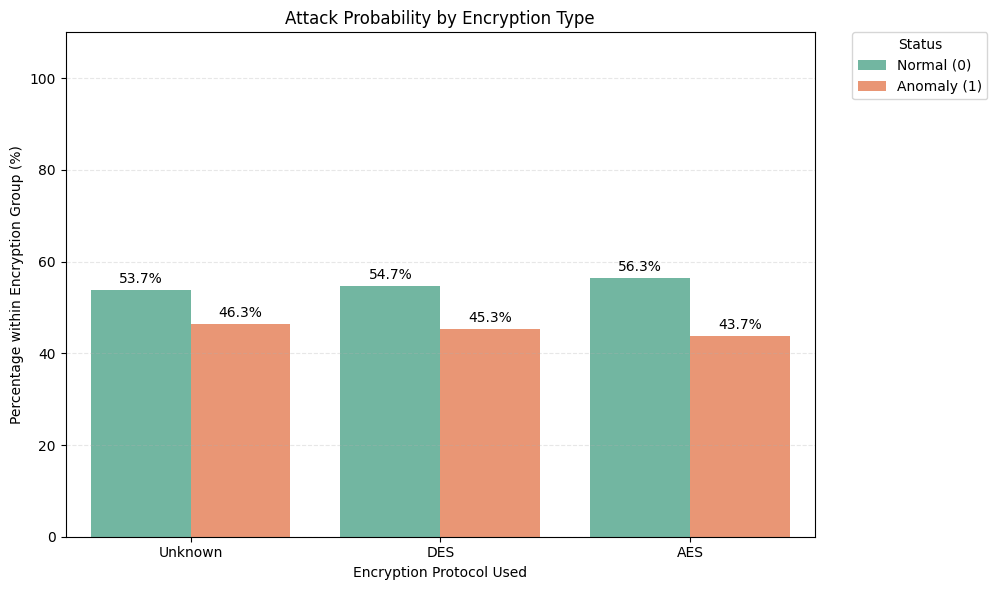

In [ ]:
# r6: Categorical/Categorical Analysis (Normalized)
# We map the values first to ensure the legend is 100% accurate
cyber_df['Attack Status'] = cyber_df['attack_detected'].map({0: 'Normal (0)', 1: 'Anomaly (1)'})

# least secure to most secure order
security_order = ['Unknown', 'DES', 'AES']

# Calculate proportions within each encryption group
props = (cyber_df.groupby("encryption_used")['Attack Status']
         .value_counts(normalize=True)
         .rename("percentage")
         .reset_index())

# Multiply by 100 for the Y-axis scale
props['percentage'] = props['percentage'] * 100

plt.figure(figsize=(10, 6))

# Plotting with the new string-based 'Attack Status'
ax = sns.barplot(data=props, x='encryption_used', y='percentage', hue='Attack Status', palette='Set2', order=security_order)

# Add percentage labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

# FIXING THE LEGEND:
# Move legend outside the plot area so it doesn't overlap the bars
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.title("Attack Probability by Encryption Type")
plt.ylabel("Percentage within Encryption Group (%)")
plt.xlabel("Encryption Protocol Used")
plt.tight_layout()
plt.ylim(0, 110) # Set limit to 110% so labels fit
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


Insight 6: The probability of attack is ~45% regardless of encryption type. 

Analsis Type: clustred countplot

How evidence was obtained: Bivariate Analysis (Categorical/Categorical R6) ---> Countplot. When looking at the countplot, you can see that when comparing the anomaly percentage in all encryption types they are roughly the same.

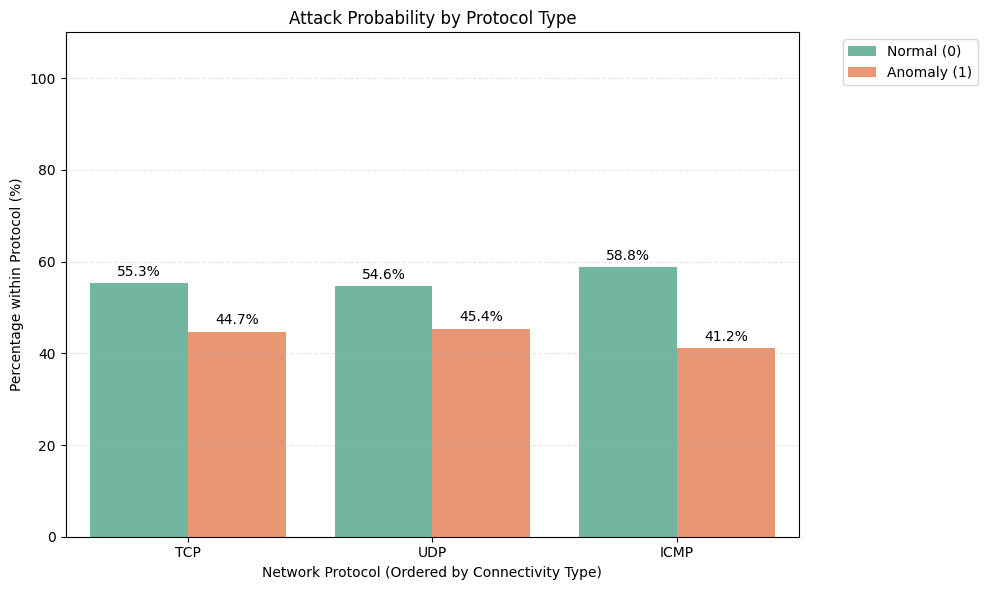

In [64]:
# r6_2: Categorical/Categorical with Manual Ordering (Protocol)

# 1. Prepare the Data
# Ensure we use the mapped columns if you created them, or map them here
cyber_df['Attack Status'] = cyber_df['attack_detected'].map({0: 'Normal (0)', 1: 'Anomaly (1)'})

# 2. Calculate Normalized Proportions (The "Fair" View)
props = (cyber_df.groupby("protocol_type")['Attack Status']
               .value_counts(normalize=True)
               .rename("percentage")
               .reset_index())

# Convert to 0-100 scale
props['percentage'] = props['percentage'] * 100

# 3. Define the Manual Order (Requirement r6)
# We order by typical network hierarchy: TCP (Standard) -> UDP (Fast) -> ICMP (Diagnostic/Risk)
protocol_order = ['TCP', 'UDP', 'ICMP']

plt.figure(figsize=(10, 6))

# 4. Create the Plot
ax = sns.barplot(
    data=props, 
    x='protocol_type', 
    y='percentage', 
    hue='Attack Status', 
    order=protocol_order, # Fulfills "set the order"
    palette='Set2'
)

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Attack Probability by Protocol Type")
plt.ylabel("Percentage within Protocol (%)")
plt.xlabel("Network Protocol (Ordered by Connectivity Type)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 110)

plt.tight_layout()
plt.show()

Insight 7: The probability of attack is ~45% regardless of protocol type. 

Analsis Type: clustred countplot

How evidence was obtained: Bivariate Analysis (Categorical/Categorical R6) ---> Countplot. When looking at the countplot, you can see that when comparing the anomaly percentage in all protocol types they are roughly the same.

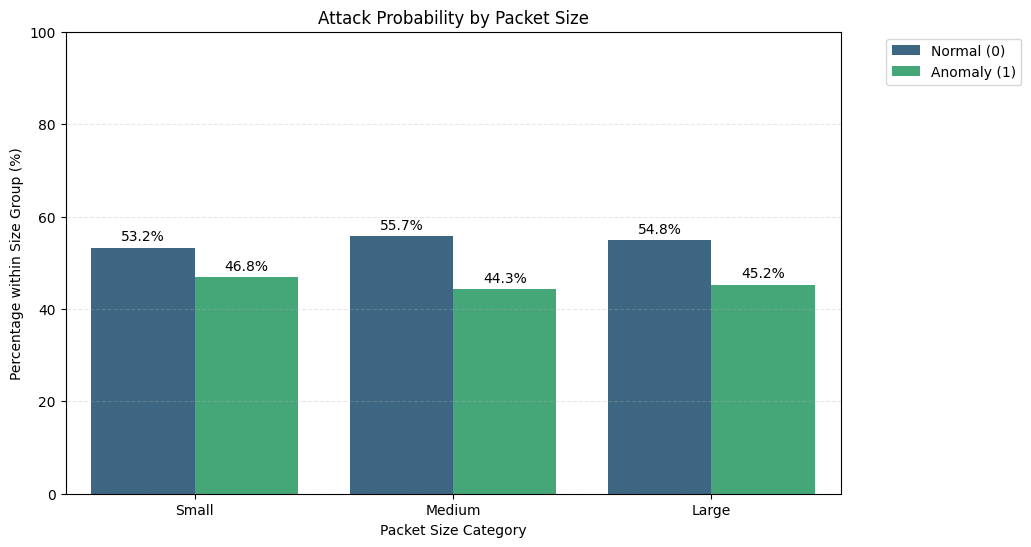

In [55]:
# r7: Categorical/Numerical with Binning
# 1. Bin the Numerical Data
# We use the edges: 0-200 (Small), 200-600 (Medium), 1000+ (Large)
bins = [0, 200, 600, 2000]
labels = ['Small', 'Medium', 'Large']
cyber_df['packet_category'] = pd.cut(cyber_df['network_packet_size'], bins=bins, labels=labels)

# 2. Map Attack Status for clarity
cyber_df['Attack Status'] = cyber_df['attack_detected'].map({0: 'Normal (0)', 1: 'Anomaly (1)'})

# 3. Calculate Normalized Proportions
props_r7 = (cyber_df.groupby("packet_category")['Attack Status']
            .value_counts(normalize=True)
            .rename("percentage")
            .reset_index())
props_r7['percentage'] = props_r7['percentage'] * 100

plt.figure(figsize=(10, 6))

# 4. Plot
ax = sns.barplot(
    data=props_r7, 
    x='packet_category', 
    y='percentage', 
    hue='Attack Status', 
    palette='viridis'
)

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Attack Probability by Packet Size")
plt.ylabel("Percentage within Size Group (%)")
plt.xlabel("Packet Size Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 100)

plt.show()

Insight 8: The probability of attack is ~45% regardless of packet size. 

Analsis Type: clustred Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Numeric R7) ---> Countplot. First we split the packet size into bins using pandas cut function to split it into 3 differnet bins, then we show the probability of attack based on bin size. 

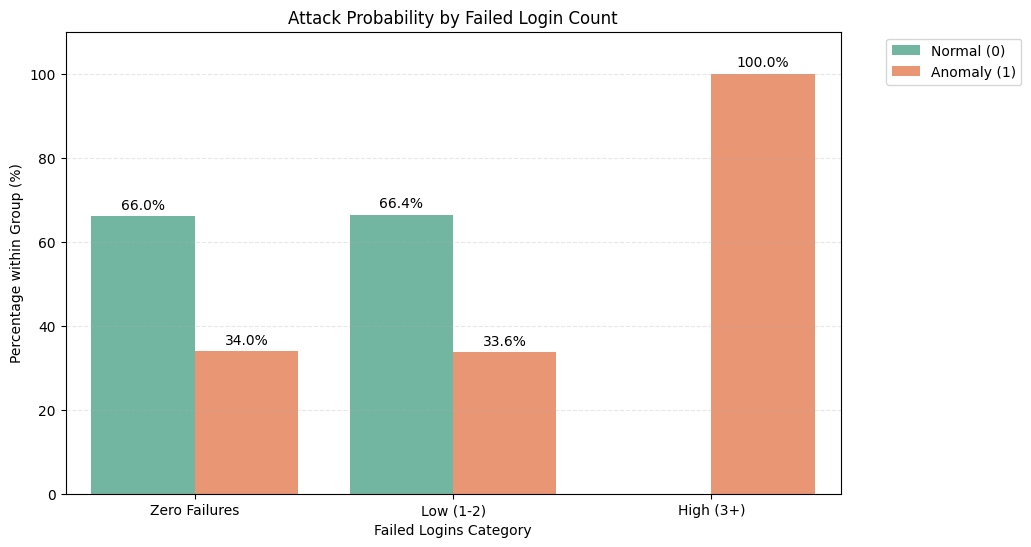

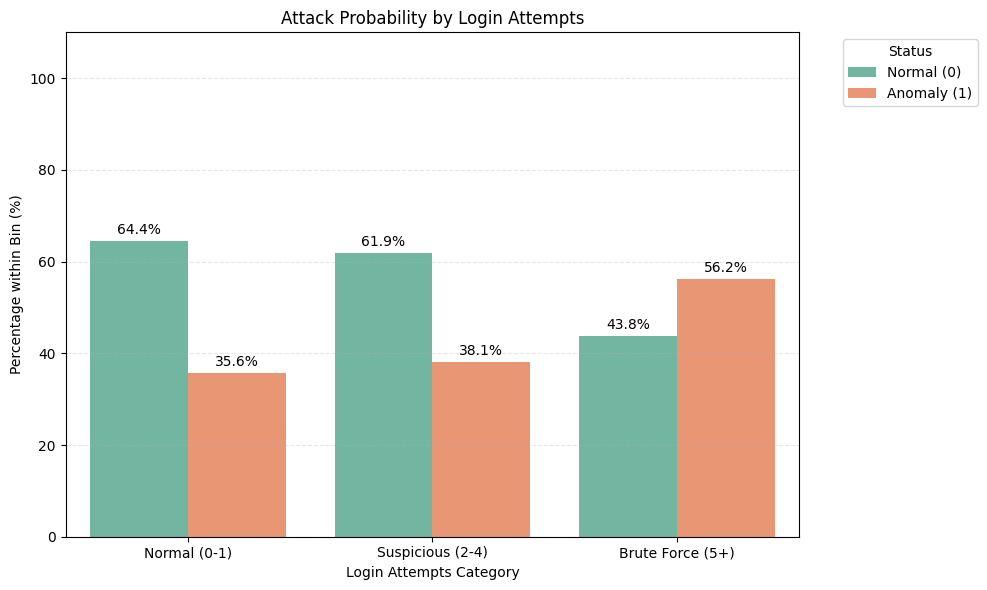

In [74]:
# r7: Categorical/Numerical with Binning (Targeting Failed Logins)
# Hypothesis: High failed logins = High Attack Probability

# 1. Create Bins: Zero(0), Low(1-2), High(3+)
bins = [-1, 0, 2, 100]
labels = ['Zero Failures', 'Low (1-2)', 'High (3+)']

cyber_df['failed_login_bin'] = pd.cut(cyber_df['failed_logins'], bins=bins, labels=labels)

# 2. Map for Clarity
cyber_df['Attack Status'] = cyber_df['attack_detected'].map({0: 'Normal (0)', 1: 'Anomaly (1)'})

# 3. Calculate Proportions
props_r7_b = (cyber_df.groupby("failed_login_bin")['Attack Status']
              .value_counts(normalize=True)
              .rename("percentage")
              .reset_index())
props_r7_b['percentage'] = props_r7_b['percentage'] * 100

# 4. Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=props_r7_b, 
    x='failed_login_bin', 
    y='percentage', 
    hue='Attack Status', 
    palette='Set2' # Using Reds to emphasize danger
)

# Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Attack Probability by Failed Login Count")
plt.ylabel("Percentage within Group (%)")
plt.xlabel("Failed Logins Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 110)

plt.show()

# r7: Categorical/Numerical with Binning (Login Attempts)
# Hypothesis: Higher login attempts correlate strongly with attacks.

# 1. Create Bins based on typical security logic
# Normal (0-1), Suspicious (2-4), Brute Force (5+)
bins = [-1, 1, 4, 100]
labels = ['Normal (0-1)', 'Suspicious (2-4)', 'Brute Force (5+)']

cyber_df['login_attempts_bin'] = pd.cut(cyber_df['login_attempts'], bins=bins, labels=labels)

# 2. Map for Plot Clarity
cyber_df['Attack Status'] = cyber_df['attack_detected'].map({0: 'Normal (0)', 1: 'Anomaly (1)'})

# 3. Calculate Normalized Proportions
props_r7_login = (cyber_df.groupby("login_attempts_bin")['Attack Status']
                  .value_counts(normalize=True)
                  .rename("percentage")
                  .reset_index())

# Convert to 0-100 scale
props_r7_login['percentage'] = props_r7_login['percentage'] * 100

plt.figure(figsize=(10, 6))

# 4. Plot using a "Red-Yellow-Green" palette to signify danger levels
ax = sns.barplot(
    data=props_r7_login, 
    x='login_attempts_bin', 
    y='percentage', 
    hue='Attack Status', 
    palette='Set2' # Reversed so Red = Brute Force (High Risk)
)

# Add Labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Attack Probability by Login Attempts")
plt.ylabel("Percentage within Bin (%)")
plt.xlabel("Login Attempts Category")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Status')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.ylim(0, 110)

plt.tight_layout()
plt.show()

Insight 9: if 5 or more failed logins attempts are detected this could indicate a high probability of attack. 

Analsis Type: clustred Countplot

How evidence was obtained: Bivariate Analysis (Categorical/Numeric R7) ---> Countplot. First we split the failed logins and login attempts into bins using pandas cut function to split it into 3 differnet bins, then we show the probability of attack based on bin size. 

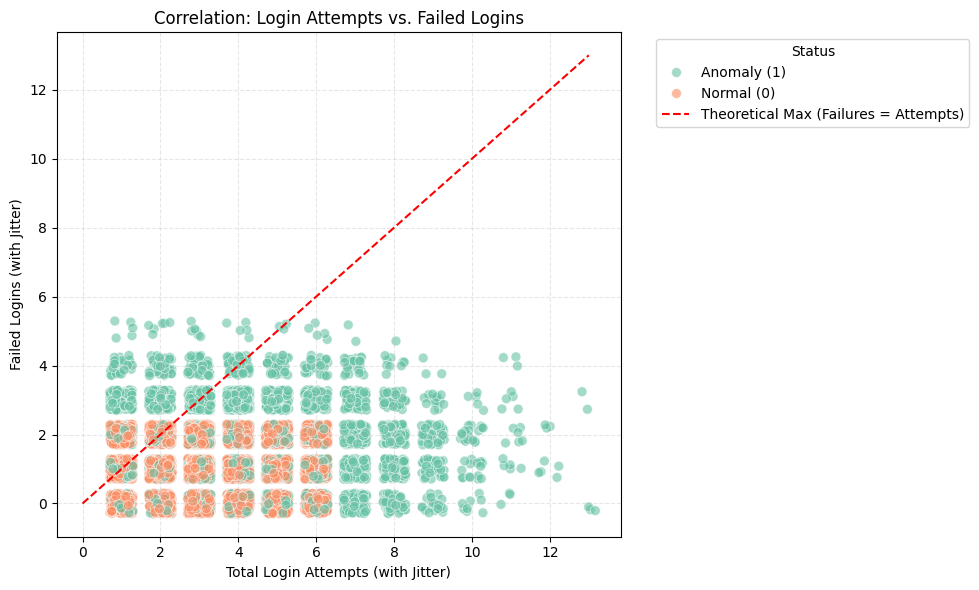

In [80]:
# r8: Numerical/Numerical Analysis (Scatterplot)
# We are checking the correlation between Login Attempts and Failed Logins.

plt.figure(figsize=(10, 6))

# 1. Add "Jitter" to handle integer overlap
# Since login counts are whole numbers (1, 2, 3), thousands of dots would hide behind each other.
# We add a tiny bit of random noise (-0.3 to +0.3) so you can see the DENSITY of the clusters.
x_jitter = cyber_df['login_attempts'] + np.random.uniform(-0.3, 0.3, len(cyber_df))
y_jitter = cyber_df['failed_logins'] + np.random.uniform(-0.3, 0.3, len(cyber_df))

# 2. Map the Target for the Legend
hue_labels = cyber_df['attack_detected'].map({0: 'Normal (0)', 1: 'Anomaly (1)'})

# 3. Create the Scatterplot
sns.scatterplot(
    x=x_jitter, 
    y=y_jitter, 
    hue=hue_labels, 
    palette='Set2', 
    alpha=0.6,  # Transparency helps show where data is dense
    s=50        # Dot size
)

# 4. Add a Reference Line (y=x)
# This red line marks the physical limit: You cannot fail more times than you try.
# Any point ABOVE this line is a data quality error.
max_val = cyber_df['login_attempts'].max()
plt.plot([0, max_val], [0, max_val], 'r--', label='Theoretical Max (Failures = Attempts)')

plt.title("Correlation: Login Attempts vs. Failed Logins")
plt.xlabel("Total Login Attempts (with Jitter)")
plt.ylabel("Failed Logins (with Jitter)")
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Insight 10: there are some data points where failed logins exceeded total attempts indicating a potential logging error in the dataset. The scatterplot displays a uniform 'grid' distribution rather than a linear trend. This indicates that login_attempts and failed_logins are independently distributed in this dataset, rather than correlated.

Analsis Type: Scatterplot

How evidence was obtained: Bivariate Analysis (Numerical/Numerical R8) ---> scatterplot. We plotted login_attempts against failed_logins. The resulting visualization formed a uniform grid structure, confirming that there is no linear dependency 

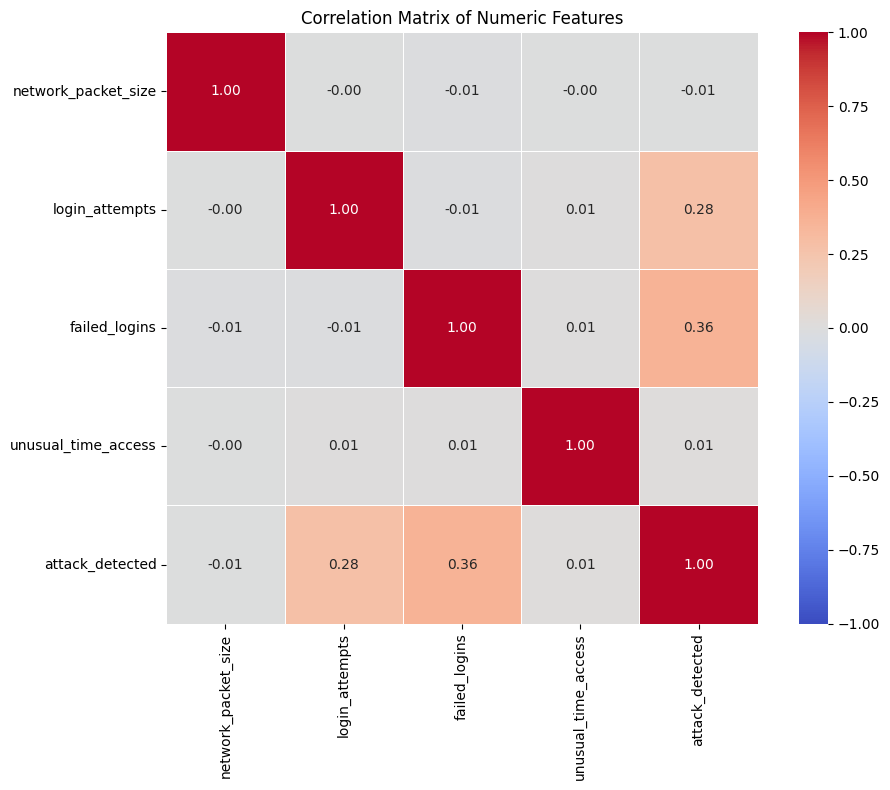

In [77]:
# r8: Numerical/Numerical Analysis (Correlation Heatmap)

# 1. Select the numerical columns you want to analyze
# We include 'attack_detected' to see which features drive the attacks
cols_to_analyze = [
    'network_packet_size', 
    'login_attempts', 
    'failed_logins', 
    'unusual_time_access', 
    'attack_detected'
]

# 2. Calculate the Correlation Matrix
# This creates a table of numbers from -1 (Perfect Negative) to +1 (Perfect Positive)
corr_matrix = cyber_df[cols_to_analyze].corr()

plt.figure(figsize=(10, 8))

# 3. Create the Heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,       # Write the actual number in the box
    fmt=".2f",        # Format to 2 decimal places
    cmap='coolwarm',  # Red = Positive Correlation, Blue = Negative
    vmin=-1, vmax=1,  # Set the scale to standard correlation limits
    linewidths=0.5,   # Add white lines between boxes for readability
    square=True
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

Insight 11: The correlation heatmap is predominantly neutral (white), indicating that individual numerical features have little to no linear relationship with the attack status. This suggests the attack vector is non-linear or highly randomized, meaning simple threshold-based detection rules would result in high false positives.

Analsis Type: Heatmap

How evidence was obtained: Bivariate Analysis (Numerical/Numerical R8) ---> heatmap. Checking the correlation between the numerical feautres in the dataset where none were found. 

References

Cyber Reconnaissance: Unveiling Attacker Strategies. (n.d.). Www.vectra.ai. https://www.vectra.ai/topics/reconnaissance

NumPy Reference — NumPy v1.19 Manual. (n.d.). Numpy.org. https://numpy.org/doc/stable/reference/index.html

stackOverflow. (2025). Stack Overflow. https://stackoverflow.com

Waskom, M. L., (2021). seaborn: statistical data visualization. Journal of Open Source Software, 6(60), 3021, https://doi.org/10.21105/joss.03021.

